# Model Benchmark Investigation

"
"This notebook complements `scripts/benchmark_models.py` with custom, thesis-oriented inspection workflows.

## 1. Aggregate Metrics Comparison

In [23]:
%matplotlib inline
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_repo_root(start: Path | None = None) -> Path:
    p = (start or Path.cwd()).resolve()
    for cand in [p, *p.parents]:
        if (cand / "src").exists() and (cand / "scripts").exists():
            return cand
    raise FileNotFoundError("Could not detect repo root (expected folders: src/, scripts/).")


REPO_ROOT = find_repo_root()
SRC_DIR = REPO_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from energy_trading.visualization.style import apply_geo_style, THESIS_PALETTE

apply_geo_style()

# -------------------------------
# Benchmark run configuration
# -------------------------------
XGB_RUN_ID = "2026-04-19T21-32-05Z"
TFT_RUN_ID = "2026-04-19T22-38-28Z"
BENCHMARK_NAME = "xgb_vs_tft"
SPLIT = "test"
LEAD = 1
WINDOW_DAYS = 5
WEEK_HOURS = 24 * 7
WEEK_REFERENCE_PRED_COL = "pred_afrr_activation_price_neg"

RUN_DIR_XGB = REPO_ROOT / "artifacts" / "model_runs" / XGB_RUN_ID
RUN_DIR_TFT = REPO_ROOT / "artifacts" / "model_runs" / TFT_RUN_ID
BENCHMARK_DIR = REPO_ROOT / "artifacts" / "benchmarks" / BENCHMARK_NAME
SUMMARY_CSV = BENCHMARK_DIR / "benchmark_summary.csv"

TRUTH_COL_BY_PRED = {
    "pred_da_price": "target_da_price",
    "pred_afrr_activation_price_pos": "target_afrr_activation_price_vwap_pos",
    "pred_afrr_activation_price_neg": "target_afrr_activation_price_vwap_neg",
    "pred_afrr_capacity_price_pos": "target_afrr_capacity_price_pos",
    "pred_afrr_capacity_price_neg": "target_afrr_capacity_price_neg",
    "pred_afrr_activation_rate_pos": "target_afrr_activation_rate_pos",
    "pred_afrr_activation_rate_neg": "target_afrr_activation_rate_neg",
}


def load_manifest(run_dir: Path) -> dict:
    mp = run_dir / "manifest.json"
    if not mp.exists():
        raise FileNotFoundError(f"Missing manifest: {mp}")
    return json.loads(mp.read_text())


def get_long_map(manifest: dict, split: str) -> dict[str, str]:
    da = manifest.get("bundles", {}).get("da", {}).get("predictions_long", {}).get(split, {})
    afrr = manifest.get("bundles", {}).get("afrr", {}).get("predictions_long", {}).get(split, {})
    return {**da, **afrr}


def resolve_truth_path(run_dir: Path, manifest: dict) -> Path:
    sm = run_dir / "summary_metrics.json"
    if sm.exists():
        payload = json.loads(sm.read_text())
        gp = payload.get("ground_truth_path", "")
        if gp and Path(gp).exists():
            return Path(gp)
    mp = manifest.get("ground_truth", {}).get("default_path", "")
    if mp and Path(mp).exists():
        return Path(mp)
    return REPO_ROOT / "data" / "features" / "all_data_features.parquet"


def load_long_df(run_dir: Path, long_map: dict[str, str], pred_col: str) -> pd.DataFrame:
    p = Path(long_map[pred_col])
    if not p.exists():
        p = run_dir / "predictions" / p.name
    if not p.exists():
        raise FileNotFoundError(f"Long prediction file not found for {pred_col}: {p}")
    df = pd.read_parquet(p)
    df["target_time_utc"] = pd.to_datetime(df["target_time_utc"], utc=True, errors="coerce")
    if "p50" not in df.columns and "predicted_value" in df.columns:
        df["p50"] = pd.to_numeric(df["predicted_value"], errors="coerce")
    return df


def load_truth_df(path: Path) -> pd.DataFrame:
    truth = pd.read_parquet(path)
    truth["timestamp_utc"] = pd.to_datetime(truth["timestamp_utc"], utc=True, errors="coerce")
    missing = [c for c in TRUTH_COL_BY_PRED.values() if c not in truth.columns]
    if missing:
        raise KeyError(f"Missing truth columns in {path}: {sorted(set(missing))}")
    return truth


mx = load_manifest(RUN_DIR_XGB)
mt = load_manifest(RUN_DIR_TFT)
xgb_long_map = get_long_map(mx, SPLIT)
tft_long_map = get_long_map(mt, SPLIT)
COMMON_PRED_COLS = sorted(set(xgb_long_map).intersection(tft_long_map).intersection(TRUTH_COL_BY_PRED))

truth_path = resolve_truth_path(RUN_DIR_XGB, mx)
truth_df = load_truth_df(truth_path)


summary_df = pd.read_csv(SUMMARY_CSV)
summary_df


,prediction_column,metric,XGBoost,TFT,Delta (%)
0,pred_afrr_activation_price_neg,MAE,368.962204,325.093897,11.889648
1,pred_afrr_activation_price_neg,RMSE,497.630396,441.576609,11.264140
2,pred_afrr_activation_price_neg,Pinball,147.663096,139.214276,5.721687
3,pred_afrr_activation_price_neg,WIS,180.023290,183.237429,-1.785402
4,pred_afrr_activation_price_neg,ACE,0.242868,0.125984,48.126433
...,...,...,...,...,...
65,pred_da_price,Skill Score,0.098897,-0.113667,-214.934569
66,pred_da_price,Spike MAE (Top 5%),59.177103,82.288655,-39.054888
67,pred_da_price,Spike RMSE (Top 5%),89.180005,120.318584,-34.916548
68,pred_da_price,Negative Tail MAE (Bottom 5%),11.244760,52.343622,-365.493448


## 2. Horizon Degradation (All Targets)

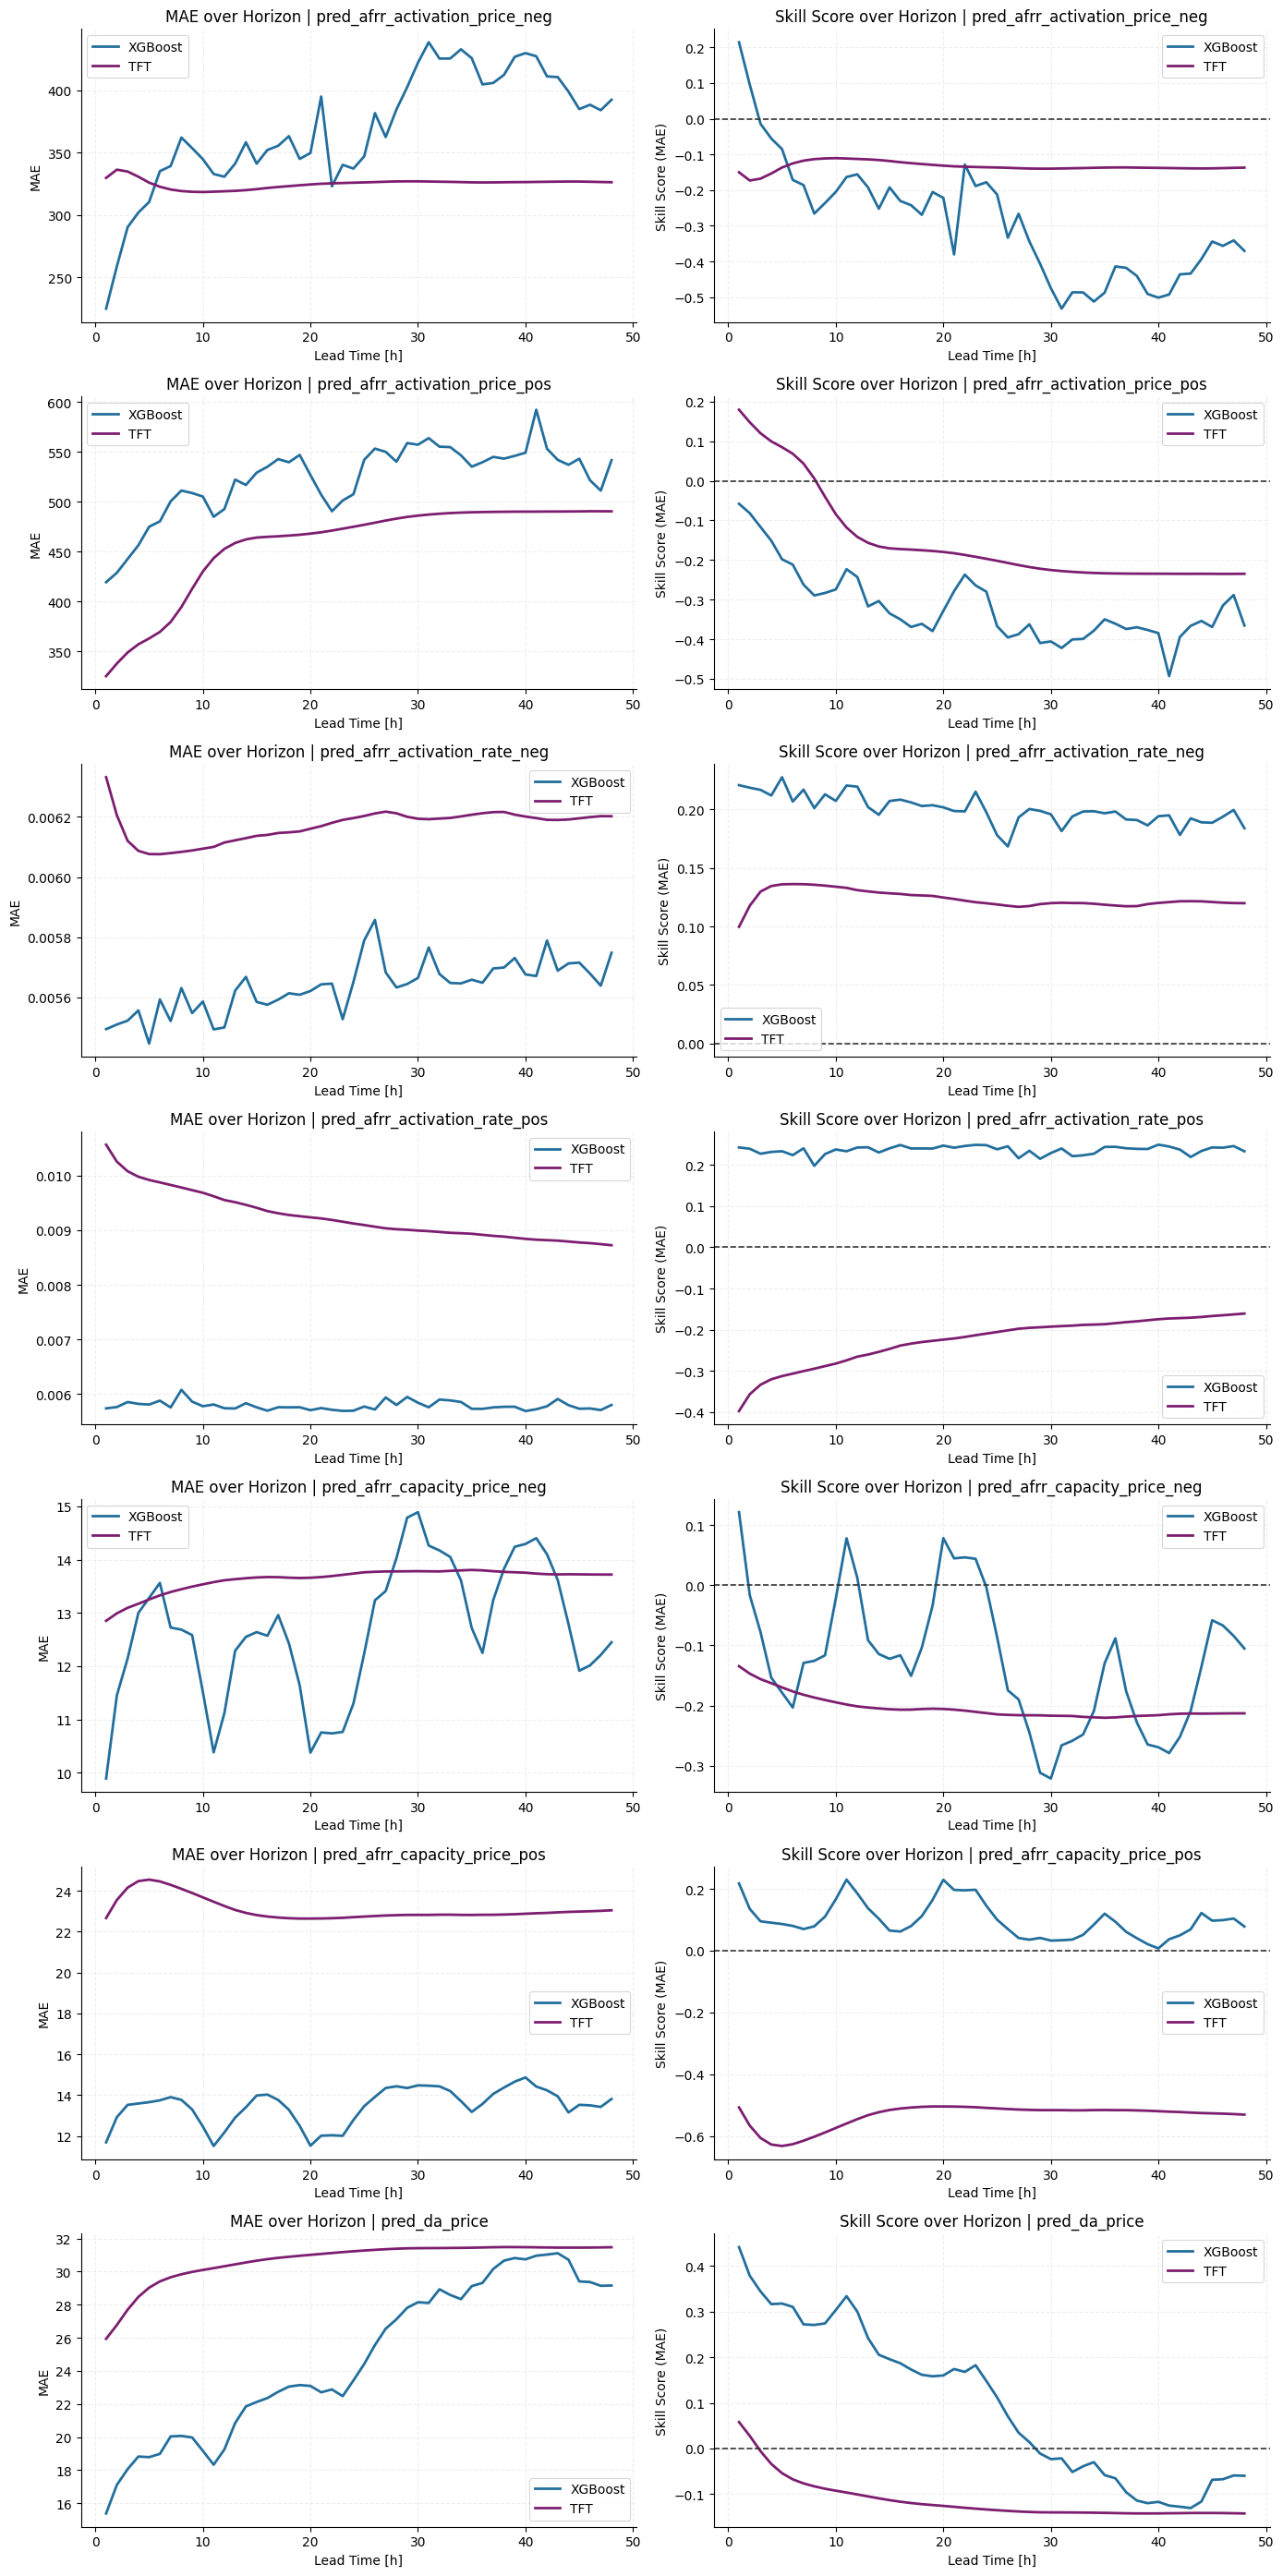

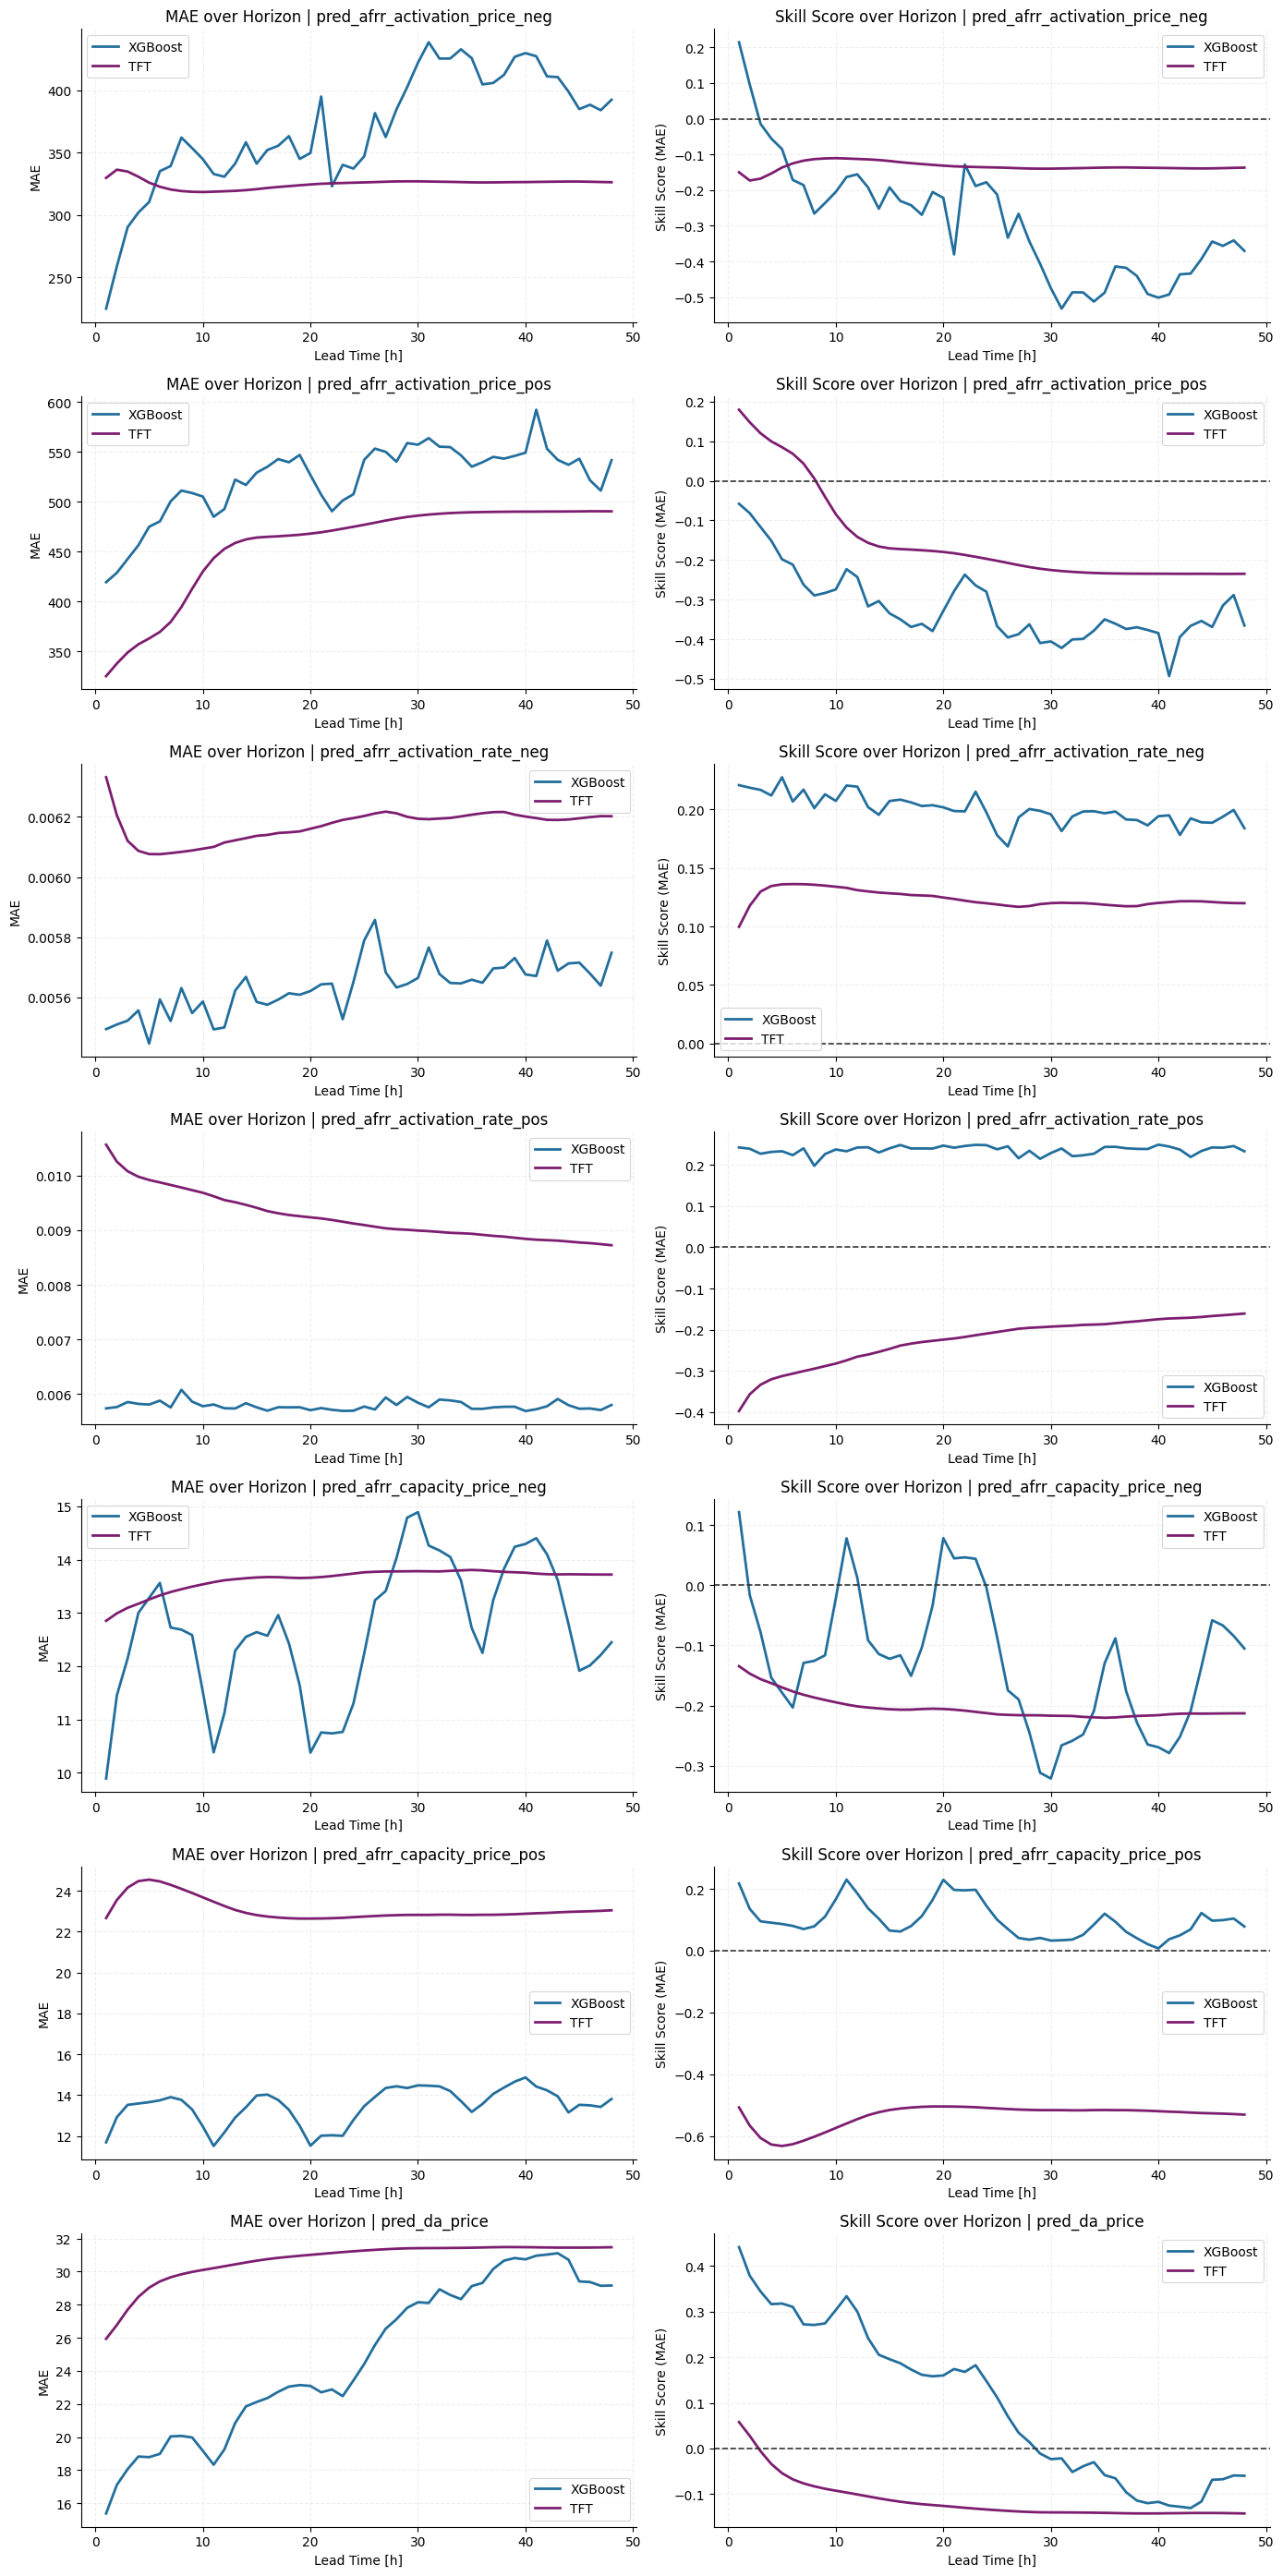

In [24]:
import math

fig, axes = plt.subplots(len(COMMON_PRED_COLS), 2, figsize=(14, 4 * len(COMMON_PRED_COLS)), squeeze=False)

for r, pred_col in enumerate(COMMON_PRED_COLS):
    xgb_lead_path = RUN_DIR_XGB / f"{SPLIT}_{pred_col}_metrics_by_lead.csv"
    tft_lead_path = RUN_DIR_TFT / f"{SPLIT}_{pred_col}_metrics_by_lead.csv"
    if not xgb_lead_path.exists() or not tft_lead_path.exists():
        axes[r, 0].text(0.5, 0.5, f"missing metrics_by_lead for {pred_col}", ha="center")
        axes[r, 1].text(0.5, 0.5, f"missing metrics_by_lead for {pred_col}", ha="center")
        continue

    xgb_lead = pd.read_csv(xgb_lead_path)
    tft_lead = pd.read_csv(tft_lead_path)

    ax0 = axes[r, 0]
    ax0.plot(xgb_lead["lead_time_h"], xgb_lead["mae"], label="XGBoost", color=THESIS_PALETTE["primary"], linewidth=2)
    ax0.plot(tft_lead["lead_time_h"], tft_lead["mae"], label="TFT", color=THESIS_PALETTE["tertiary"], linewidth=2)
    ax0.set_title(f"MAE over Horizon | {pred_col}")
    ax0.set_xlabel("Lead Time [h]")
    ax0.set_ylabel("MAE")
    ax0.legend()

    ax1 = axes[r, 1]
    if "skill_score_mae" in xgb_lead.columns and "skill_score_mae" in tft_lead.columns:
        ax1.plot(xgb_lead["lead_time_h"], xgb_lead["skill_score_mae"], label="XGBoost", color=THESIS_PALETTE["primary"], linewidth=2)
        ax1.plot(tft_lead["lead_time_h"], tft_lead["skill_score_mae"], label="TFT", color=THESIS_PALETTE["tertiary"], linewidth=2)
        ax1.axhline(0.0, color=THESIS_PALETTE["neutral_dark"], linestyle="--", linewidth=1.2)
        ax1.set_ylabel("Skill Score (MAE)")
    else:
        ax1.text(0.5, 0.5, "skill_score_mae not found", ha="center")
    ax1.set_title(f"Skill Score over Horizon | {pred_col}")
    ax1.set_xlabel("Lead Time [h]")
    ax1.legend(loc="best")

plt.tight_layout()
fig


## 3. Weekly Truth vs Predictions (Mon-Sun, All Targets)

Global week reference target: pred_afrr_activation_price_neg
High-vol week start (UTC Monday): 2025-09-22 00:00:00+00:00
Typical week start (UTC Monday): 2026-02-16 00:00:00+00:00


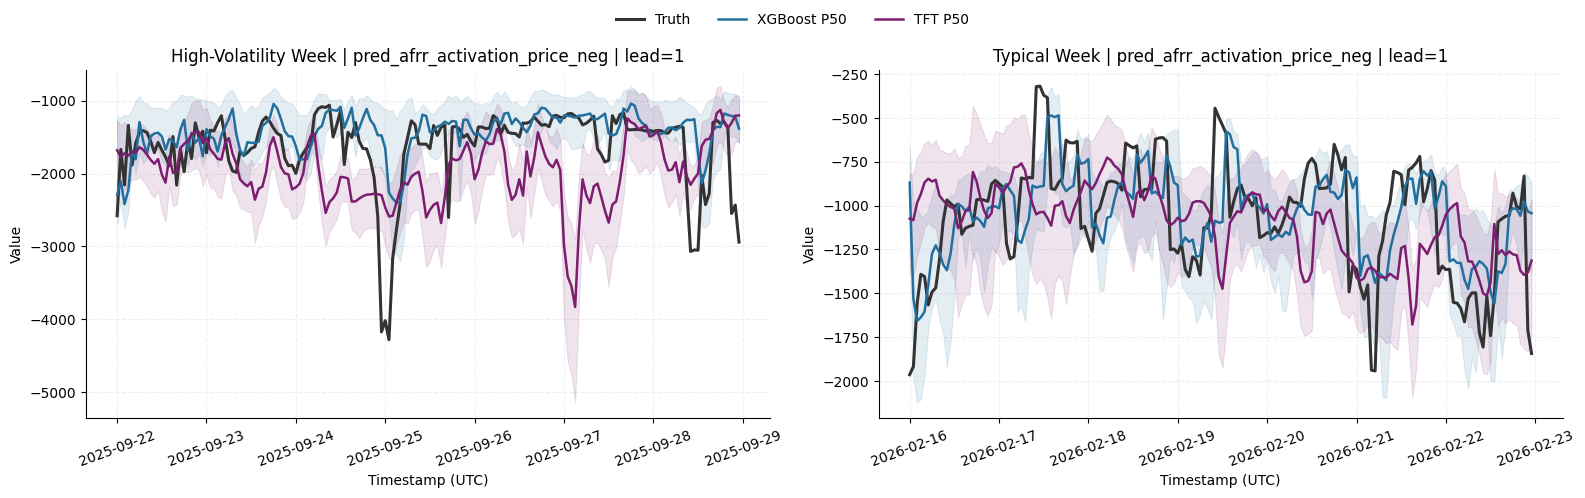

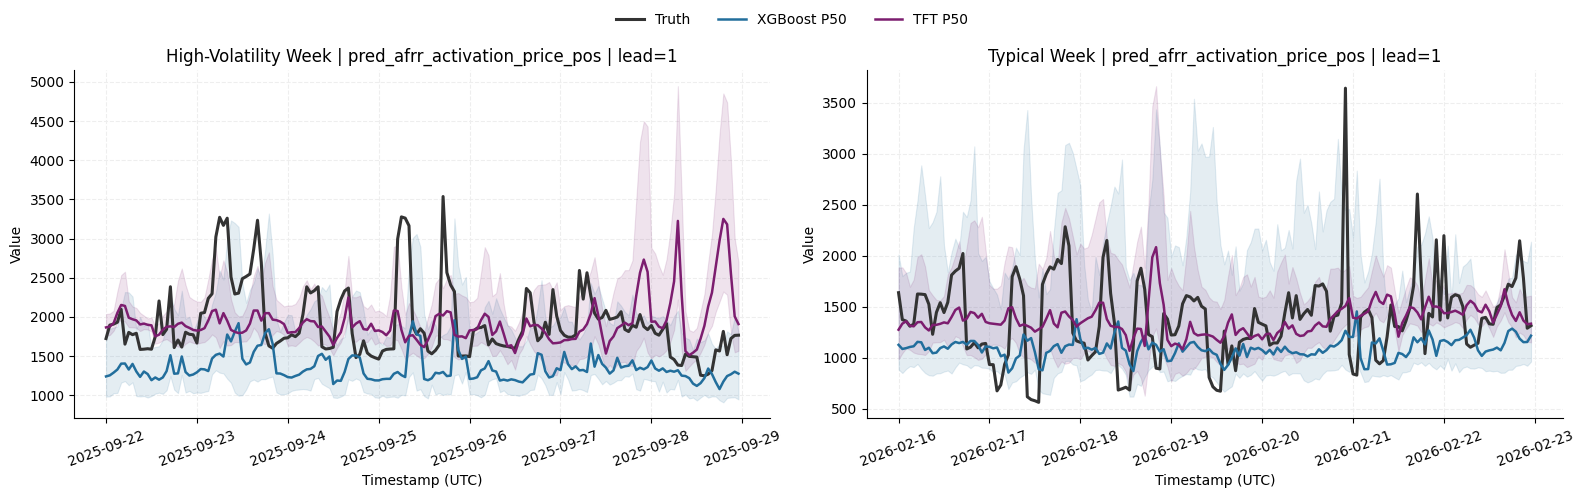

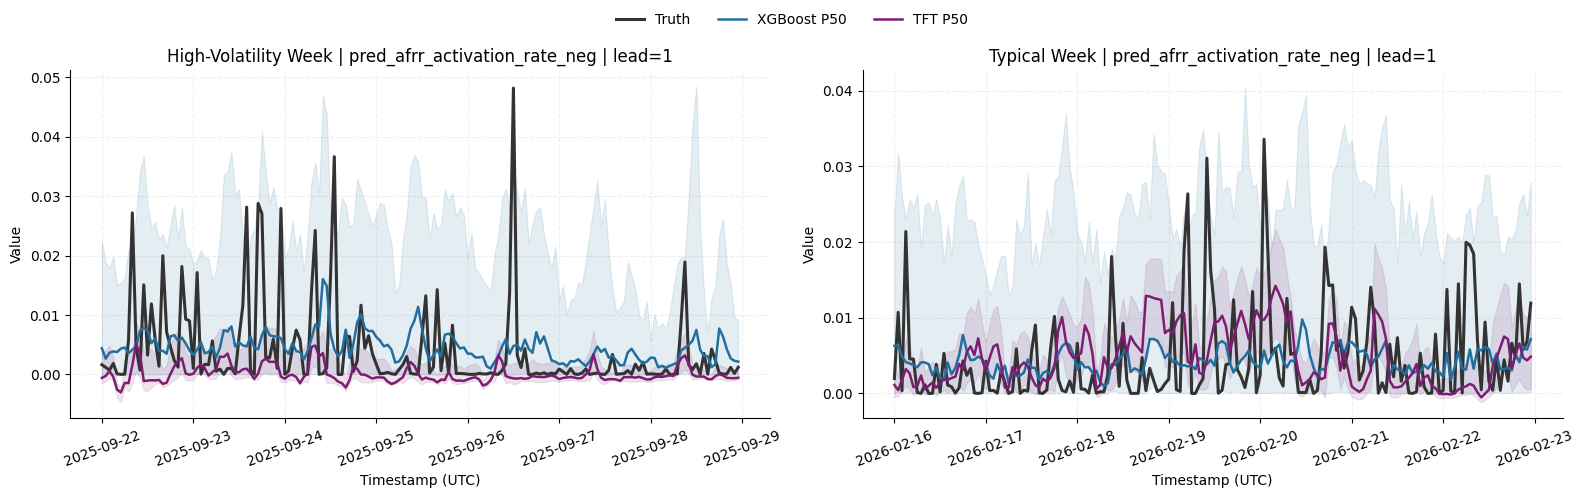

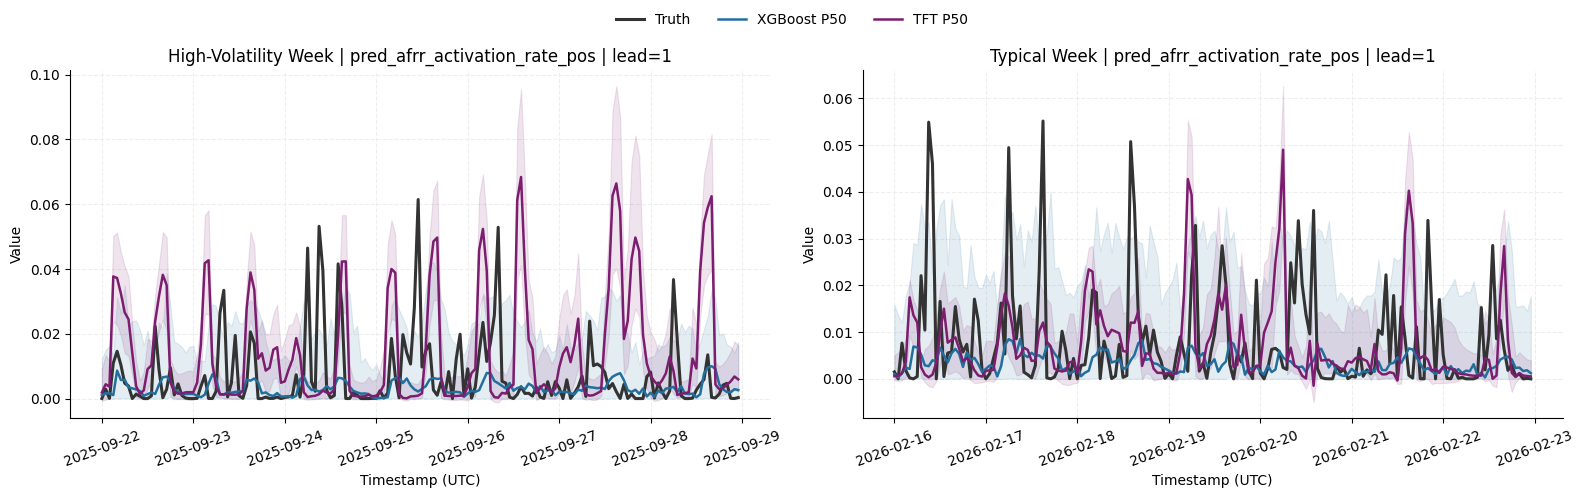

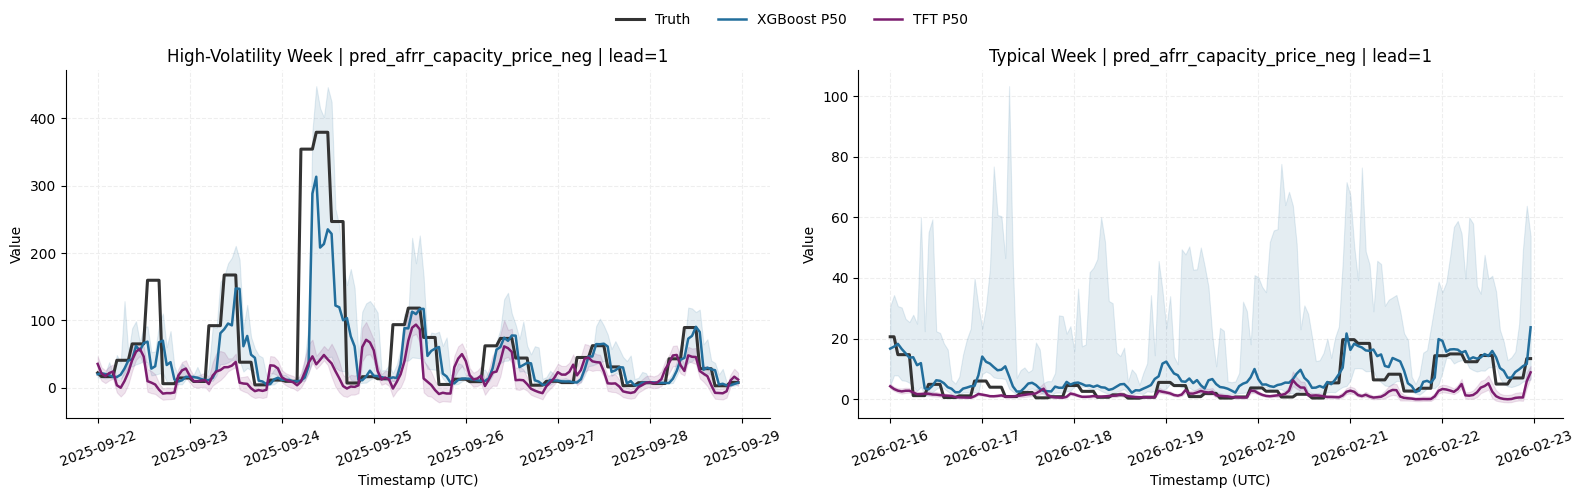

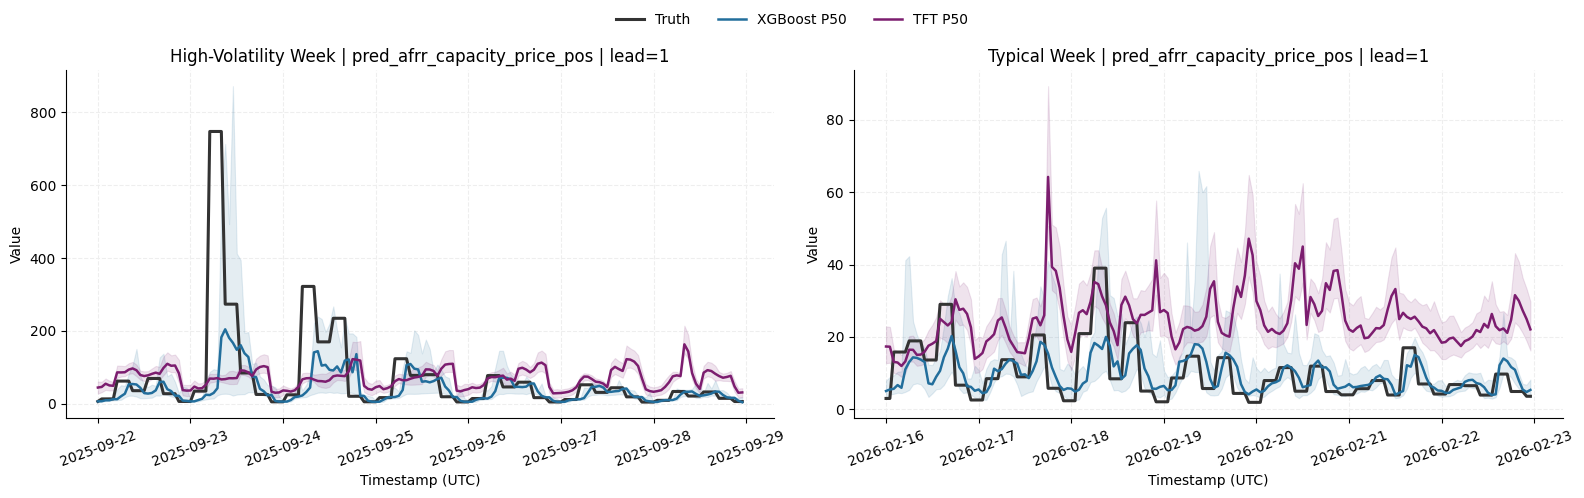

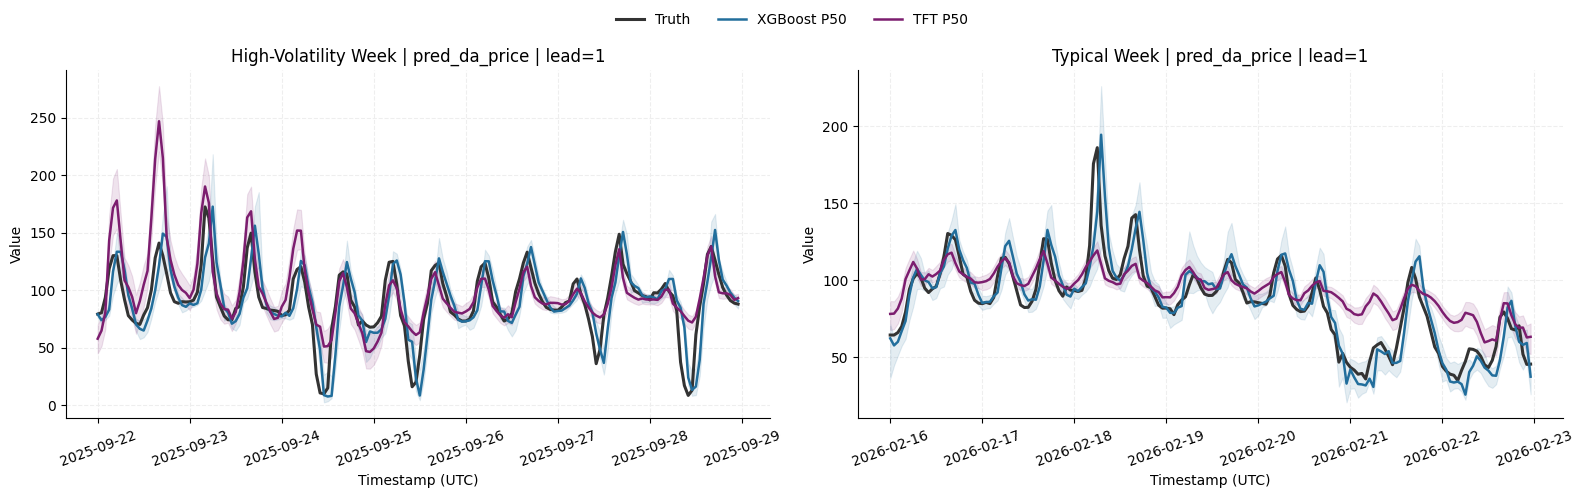

In [25]:
def load_merged_for_target(pred_col: str, lead: int = 1) -> pd.DataFrame:
    truth_col = TRUTH_COL_BY_PRED[pred_col]

    xgb = load_long_df(RUN_DIR_XGB, xgb_long_map, pred_col)
    tft = load_long_df(RUN_DIR_TFT, tft_long_map, pred_col)

    xgb_l = xgb.loc[xgb["lead_time_h"] == lead, ["target_time_utc", "p50"]].rename(columns={"p50": "xgb_p50"})
    tft_l = tft.loc[tft["lead_time_h"] == lead, ["target_time_utc", "p50"]].rename(columns={"p50": "tft_p50"})

    xgb_q = xgb.loc[xgb["lead_time_h"] == lead, ["target_time_utc", "p10", "p90"]] if {"p10", "p90"}.issubset(xgb.columns) else None
    tft_q = tft.loc[tft["lead_time_h"] == lead, ["target_time_utc", "p10", "p90"]] if {"p10", "p90"}.issubset(tft.columns) else None

    tru = truth_df[["timestamp_utc", truth_col]].rename(columns={"timestamp_utc": "target_time_utc", truth_col: "y_true"})

    merged = tru.merge(xgb_l, on="target_time_utc", how="inner").merge(tft_l, on="target_time_utc", how="inner")
    if xgb_q is not None:
        merged = merged.merge(xgb_q.rename(columns={"p10": "xgb_p10", "p90": "xgb_p90"}), on="target_time_utc", how="left")
    if tft_q is not None:
        merged = merged.merge(tft_q.rename(columns={"p10": "tft_p10", "p90": "tft_p90"}), on="target_time_utc", how="left")

    return merged.sort_values("target_time_utc").reset_index(drop=True)


def _monday_start(ts: pd.Timestamp) -> pd.Timestamp:
    ts = pd.Timestamp(ts).tz_convert("UTC")
    return (ts - pd.Timedelta(days=int(ts.weekday()))).floor("D")


def _week_slice_by_start(df: pd.DataFrame, week_start_utc: pd.Timestamp) -> pd.DataFrame:
    start = pd.Timestamp(week_start_utc).tz_convert("UTC")
    end = start + pd.Timedelta(days=7)
    out = df[(df["target_time_utc"] >= start) & (df["target_time_utc"] < end)].copy()
    return out


def _compute_global_week_starts(reference_pred_col: str) -> tuple[pd.Timestamp, pd.Timestamp]:
    ref = load_merged_for_target(reference_pred_col, lead=LEAD)
    if ref.empty:
        fallback = load_merged_for_target(COMMON_PRED_COLS[0], lead=LEAD)
        ref = fallback
    if ref.empty:
        raise ValueError("No merged data available to determine weekly windows.")

    d = ref.sort_values("target_time_utc").reset_index(drop=True)
    rolling_std = d["y_true"].rolling(window=WEEK_HOURS, min_periods=24 * 3).std()

    if rolling_std.notna().any():
        high_anchor = d.loc[int(rolling_std.idxmax()), "target_time_utc"]
        rs = rolling_std.dropna()
        med = rs.median()
        typical_idx = (rs - med).abs().idxmin()
        typical_anchor = d.loc[int(typical_idx), "target_time_utc"]
    else:
        high_anchor = d["target_time_utc"].iloc[min(len(d) - 1, max(0, WEEK_HOURS - 1))]
        typical_anchor = d["target_time_utc"].iloc[len(d) // 2]

    high_start = _monday_start(high_anchor)
    typical_start = _monday_start(typical_anchor)
    if high_start == typical_start:
        alt_anchor = d["target_time_utc"].iloc[len(d) // 2]
        typical_start = _monday_start(alt_anchor)

    return high_start, typical_start


reference_col = WEEK_REFERENCE_PRED_COL if WEEK_REFERENCE_PRED_COL in COMMON_PRED_COLS else COMMON_PRED_COLS[0]
HIGH_WEEK_START_UTC, TYPICAL_WEEK_START_UTC = _compute_global_week_starts(reference_col)

print(f"Global week reference target: {reference_col}")
print(f"High-vol week start (UTC Monday): {HIGH_WEEK_START_UTC}")
print(f"Typical week start (UTC Monday): {TYPICAL_WEEK_START_UTC}")

for pred_col in COMMON_PRED_COLS:
    merged = load_merged_for_target(pred_col, lead=LEAD)
    if merged.empty:
        continue

    high_week = _week_slice_by_start(merged, HIGH_WEEK_START_UTC)
    typical_week = _week_slice_by_start(merged, TYPICAL_WEEK_START_UTC)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=False)
    for ax, view, title_suffix, start_utc in [
        (axes[0], high_week, "High-Volatility Week", HIGH_WEEK_START_UTC),
        (axes[1], typical_week, "Typical Week", TYPICAL_WEEK_START_UTC),
    ]:
        if view.empty:
            ax.text(0.5, 0.5, "No data", ha="center", va="center")
            ax.set_title(f"{title_suffix} | {pred_col}")
            continue

        ax.plot(view["target_time_utc"], view["y_true"], label="Truth", color=THESIS_PALETTE["neutral_dark"], linewidth=2.2)
        ax.plot(view["target_time_utc"], view["xgb_p50"], label="XGBoost P50", color=THESIS_PALETTE["primary"], linewidth=1.8)
        ax.plot(view["target_time_utc"], view["tft_p50"], label="TFT P50", color=THESIS_PALETTE["tertiary"], linewidth=1.8)

        if {"xgb_p10", "xgb_p90"}.issubset(view.columns):
            ax.fill_between(view["target_time_utc"], view["xgb_p10"], view["xgb_p90"], color=THESIS_PALETTE["primary"], alpha=0.12)
        if {"tft_p10", "tft_p90"}.issubset(view.columns):
            ax.fill_between(view["target_time_utc"], view["tft_p10"], view["tft_p90"], color=THESIS_PALETTE["tertiary"], alpha=0.12)

        ax.set_title(f"{title_suffix} | {pred_col} | lead={LEAD}")
        ax.set_xlabel("Timestamp (UTC)")
        ax.set_ylabel("Value")
        ax.tick_params(axis="x", rotation=20)

    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False)
    fig.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()


## 4. Event Window Deep Dive (Selected Target, Mon-Sun)

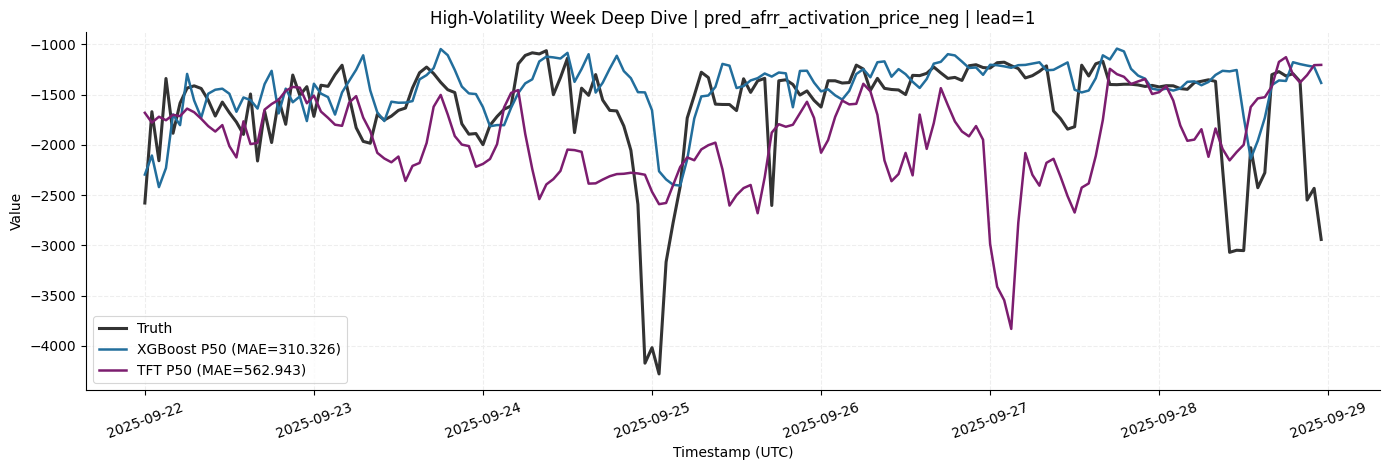

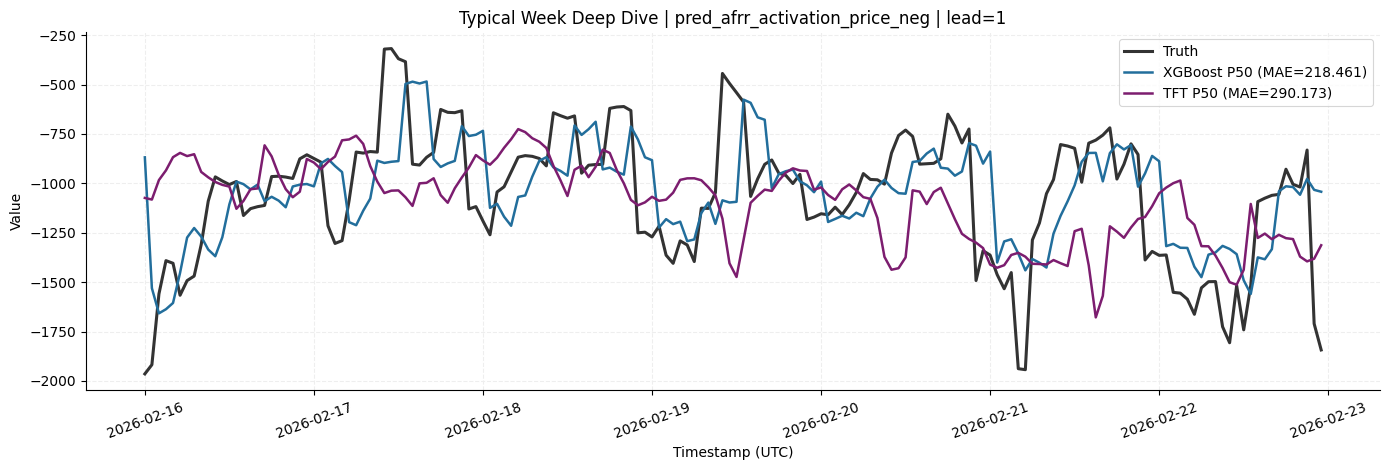

In [26]:
# Optional focused deep-dive for one target (uses SAME global weeks as section 3)
SELECTED_PRED_COL = "pred_afrr_activation_price_neg"

merged = load_merged_for_target(SELECTED_PRED_COL, lead=LEAD)
high_week = _week_slice_by_start(merged, HIGH_WEEK_START_UTC)
typical_week = _week_slice_by_start(merged, TYPICAL_WEEK_START_UTC)

for label, view, start_utc in [
    ("High-Volatility", high_week, HIGH_WEEK_START_UTC),
    ("Typical", typical_week, TYPICAL_WEEK_START_UTC),
]:
    if view.empty:
        continue
    mae_xgb = (view["xgb_p50"] - view["y_true"]).abs().mean()
    mae_tft = (view["tft_p50"] - view["y_true"]).abs().mean()

    plt.figure(figsize=(14, 4.8))
    plt.plot(view["target_time_utc"], view["y_true"], label="Truth", color=THESIS_PALETTE["neutral_dark"], linewidth=2.2)
    plt.plot(view["target_time_utc"], view["xgb_p50"], label=f"XGBoost P50 (MAE={mae_xgb:.3f})", color=THESIS_PALETTE["primary"], linewidth=1.8)
    plt.plot(view["target_time_utc"], view["tft_p50"], label=f"TFT P50 (MAE={mae_tft:.3f})", color=THESIS_PALETTE["tertiary"], linewidth=1.8)
    plt.title(f"{label} Week Deep Dive | {SELECTED_PRED_COL} | lead={LEAD}")
    plt.xlabel("Timestamp (UTC)")
    plt.ylabel("Value")
    plt.xticks(rotation=20)
    plt.legend()
    plt.tight_layout()
    plt.show()


## 4. Residual & Bias Analysis

In [27]:
# Build df for residual/regime analysis if not already provided
# Expected columns afterwards: target_time_utc, y_true, xgb_p50, tft_p50
ANALYSIS_PRED_COL = globals().get("SELECTED_PRED_COL", globals().get("WEEK_REFERENCE_PRED_COL", None))
if ANALYSIS_PRED_COL is None:
    ANALYSIS_PRED_COL = COMMON_PRED_COLS[0]

if "df" not in globals() or df is None:
    df = load_merged_for_target(ANALYSIS_PRED_COL, lead=LEAD)

required_cols = {"target_time_utc", "y_true", "xgb_p50", "tft_p50"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(
        f"df is missing required columns for Sections 4/5: {sorted(missing)}. "
        f"Current columns: {list(df.columns)}"
    )

print(f"Using ANALYSIS_PRED_COL={ANALYSIS_PRED_COL}, rows={len(df):,}")


Using ANALYSIS_PRED_COL=pred_afrr_activation_price_neg, rows=14,402


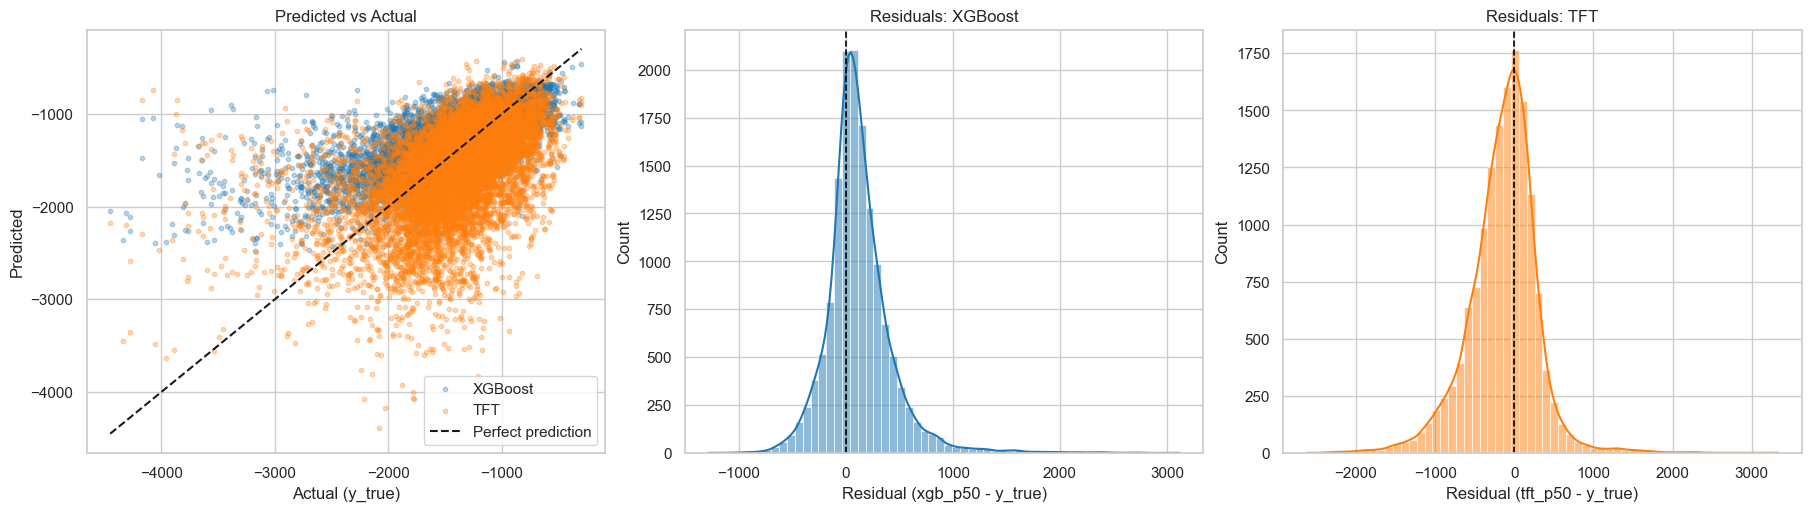

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Expected columns in df: target_time_utc, y_true, xgb_p50, tft_p50
d = globals()["df"].copy()
d["target_time_utc"] = pd.to_datetime(d["target_time_utc"], utc=True, errors="coerce")
for c in ["y_true", "xgb_p50", "tft_p50"]:
    d[c] = pd.to_numeric(d[c], errors="coerce")
d = d.dropna(subset=["target_time_utc", "y_true", "xgb_p50", "tft_p50"]).sort_values("target_time_utc")

d["res_xgb"] = d["xgb_p50"] - d["y_true"]
d["res_tft"] = d["tft_p50"] - d["y_true"]

sns.set_theme(style="whitegrid")
xgb_color = "#1f77b4"
tft_color = "#ff7f0e"

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

# 1) Predicted vs Actual
ax = axes[0]
ax.scatter(d["y_true"], d["xgb_p50"], s=10, alpha=0.3, color=xgb_color, label="XGBoost")
ax.scatter(d["y_true"], d["tft_p50"], s=10, alpha=0.3, color=tft_color, label="TFT")
vmin = float(np.nanmin([d["y_true"].min(), d["xgb_p50"].min(), d["tft_p50"].min()]))
vmax = float(np.nanmax([d["y_true"].max(), d["xgb_p50"].max(), d["tft_p50"].max()]))
ax.plot([vmin, vmax], [vmin, vmax], "k--", lw=1.5, label="Perfect prediction")
ax.set_xlabel("Actual (y_true)")
ax.set_ylabel("Predicted")
ax.set_title("Predicted vs Actual")
ax.legend(frameon=True)

# 2) Residual histogram XGB
ax = axes[1]
sns.histplot(d["res_xgb"], bins=60, kde=True, color=xgb_color, ax=ax)
ax.axvline(0, color="black", linestyle="--", linewidth=1.2)
ax.set_xlabel("Residual (xgb_p50 - y_true)")
ax.set_ylabel("Count")
ax.set_title("Residuals: XGBoost")

# 3) Residual histogram TFT
ax = axes[2]
sns.histplot(d["res_tft"], bins=60, kde=True, color=tft_color, ax=ax)
ax.axvline(0, color="black", linestyle="--", linewidth=1.2)
ax.set_xlabel("Residual (tft_p50 - y_true)")
ax.set_ylabel("Count")
ax.set_title("Residuals: TFT")

plt.show()


## 5. Temporal Error Regimes

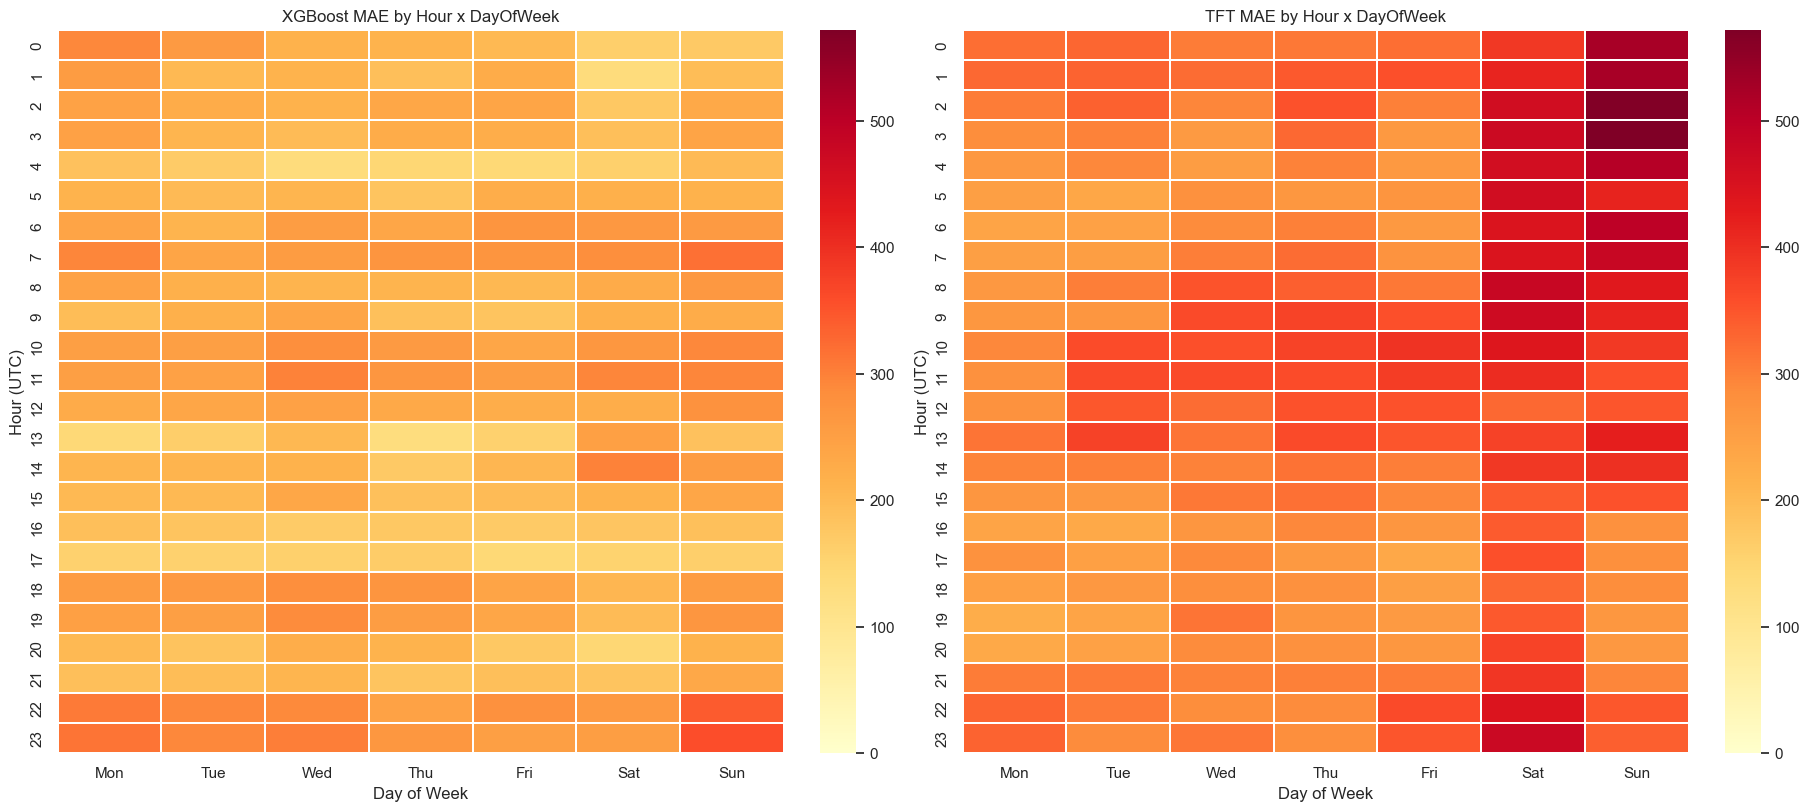

Delta Heatmap (XGB MAE - TFT MAE):


,Mon,Tue,Wed,Thu,Fri,Sat,Sun
hour,,,,,,,
0,-29.6192,-69.7620,-87.9370,-95.1936,-119.4115,-225.9606,-348.7374
1,-67.8873,-132.6562,-109.6107,-153.6411,-129.4874,-281.6592,-327.0158
2,-60.3127,-109.6449,-77.1598,-118.6915,-59.8744,-288.3171,-336.4876
3,-38.2079,-89.3463,-61.9623,-100.0302,-36.2908,-280.5631,-328.7477
4,-79.5460,-123.3298,-121.3541,-152.9075,-118.9510,-301.3925,-306.8087
5,-38.5351,-36.3871,-70.8202,-83.4438,-45.3823,-246.3645,-202.1751
6,0.6635,-35.5361,-32.2253,-60.9404,7.0734,-179.9663,-235.6126
7,41.5523,-14.4605,-45.0015,-51.1220,-1.7986,-163.1956,-163.4713
8,-20.9979,-83.1454,-141.5728,-127.9616,-104.6201,-251.9289,-169.2187


In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

d = globals()["df"].copy()
d["target_time_utc"] = pd.to_datetime(d["target_time_utc"], utc=True, errors="coerce")
for c in ["y_true", "xgb_p50", "tft_p50"]:
    d[c] = pd.to_numeric(d[c], errors="coerce")
d = d.dropna(subset=["target_time_utc", "y_true", "xgb_p50", "tft_p50"]).sort_values("target_time_utc")

d["hour"] = d["target_time_utc"].dt.hour
d["dayofweek"] = d["target_time_utc"].dt.dayofweek  # Mon=0 ... Sun=6

d["ae_xgb"] = (d["xgb_p50"] - d["y_true"]).abs()
d["ae_tft"] = (d["tft_p50"] - d["y_true"]).abs()

hour_index = list(range(24))
dow_index = list(range(7))
dow_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

xgb_heat = (
    d.groupby(["hour", "dayofweek"], as_index=False)["ae_xgb"].mean()
    .pivot(index="hour", columns="dayofweek", values="ae_xgb")
    .reindex(index=hour_index, columns=dow_index)
)
tft_heat = (
    d.groupby(["hour", "dayofweek"], as_index=False)["ae_tft"].mean()
    .pivot(index="hour", columns="dayofweek", values="ae_tft")
    .reindex(index=hour_index, columns=dow_index)
)

xgb_heat.columns = dow_labels
tft_heat.columns = dow_labels

vmax = float(np.nanmax([xgb_heat.to_numpy(), tft_heat.to_numpy()]))

sns.set_theme(style="white")
fig, axes = plt.subplots(1, 2, figsize=(18, 8), constrained_layout=True)

sns.heatmap(
    xgb_heat, ax=axes[0], cmap="YlOrRd", vmin=0, vmax=vmax,
    cbar=True, linewidths=0.2, linecolor="white"
)
axes[0].set_title("XGBoost MAE by Hour x DayOfWeek")
axes[0].set_xlabel("Day of Week")
axes[0].set_ylabel("Hour (UTC)")

sns.heatmap(
    tft_heat, ax=axes[1], cmap="YlOrRd", vmin=0, vmax=vmax,
    cbar=True, linewidths=0.2, linecolor="white"
)
axes[1].set_title("TFT MAE by Hour x DayOfWeek")
axes[1].set_xlabel("Day of Week")
axes[1].set_ylabel("Hour (UTC)")

plt.show()

delta_heat = xgb_heat - tft_heat
print("Delta Heatmap (XGB MAE - TFT MAE):")
display(delta_heat.round(4))
